In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa
from itertools import combinations
from scipy.stats import spearmanr, kendalltau
import math
import os
import scipy.stats as stats
import kaleido

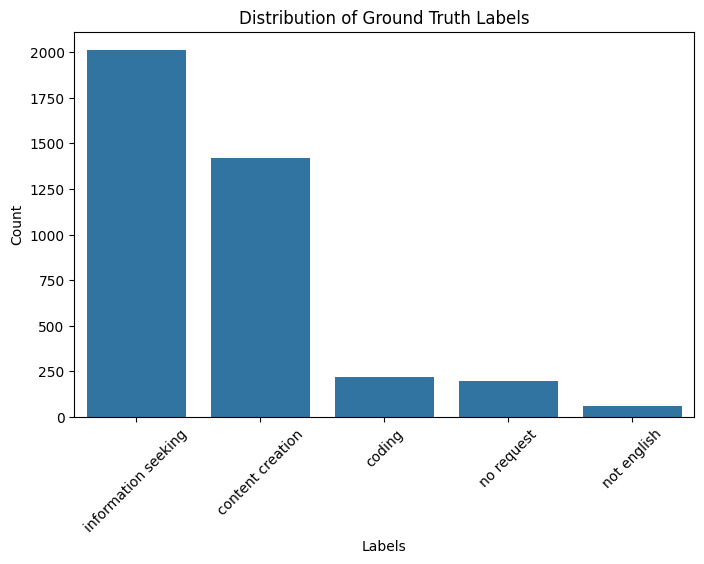

In [2]:
df = pd.read_csv("data_prompts/info-non-info-dataset.csv")
df["dataset"] = ["SES" if i == "en_elisa" or i == "elisa" else i.replace("en_", "") for i in df.dataset.tolist()]
#plot the distribution of the ground truth labels
plt.figure(figsize=(8,5))
sns.countplot(x='ground_truth', data=df, order=df['ground_truth'].value_counts().index)
plt.title("Distribution of Ground Truth Labels")
plt.xlabel("Labels")
plt.ylabel("Count")
# change rotation of x labels
plt.xticks(rotation=45)
plt.show()

## Number of queries in each dataset

In [13]:
df_all = pd.DataFrame()
files = glob.glob("/data1/shared_datasets/project-info-seeking/user_conversations/datasets_filtered/*history.csv")
for file in files: 
    print(file)
    df = pd.read_csv(file)
    dataset = file.split("/")[-1].split("_history.csv")[0]
    df["dataset"] = dataset
    print(len(df))
    df_all = pd.concat([df_all, df], ignore_index=True)
print(df_all["dataset"].value_counts())
print(len(df_all))

/data1/shared_datasets/project-info-seeking/user_conversations/datasets_filtered/en_lmsys-chat-1m_history.csv
1056100
/data1/shared_datasets/project-info-seeking/user_conversations/datasets_filtered/en_SES_history.csv
6527
/data1/shared_datasets/project-info-seeking/user_conversations/datasets_filtered/en_ShareGPT_history.csv
333941
/data1/shared_datasets/project-info-seeking/user_conversations/datasets_filtered/en_WildChat_history.csv
444019
dataset
en_lmsys-chat-1m    1056100
en_WildChat          444019
en_ShareGPT          333941
en_SES                 6527
Name: count, dtype: int64
1840587


In [2]:
df_all = pd.DataFrame()
files = glob.glob("/data1/shared_datasets/project-info-seeking/user_conversations/predictions_infoseek/*history.csv")
for file in files: 
    df = pd.read_csv(file)
    dataset = file.split("/")[-1].split("_history.csv")[0]
    df["dataset"] = dataset
    df_all = pd.concat([df_all, df], ignore_index=True)
print(df_all["dataset"].value_counts())
print(len(df_all))
df_all["prediction"].value_counts()/len(df_all)

dataset
preds_en_lmsys-chat-1m    1056099
preds_en_WildChat          444019
preds_en_ShareGPT          333482
preds_en_SES                 6526
Name: count, dtype: int64
1840126


prediction
content creation       0.411682
information seeking    0.397441
coding                 0.082844
no request             0.080893
not english            0.027140
Name: count, dtype: float64

In [24]:
color_map = {
    "information seeking": "#66c2a5",
    "": "#fc8d62",
    'coding': "#8da0cb",
    'content creation': "#e78ac3",
    "": "#a6d854",
    "no request": "#ffd92f",
    'not english': "#B0B0B0"
}

response_proportions = df_all.groupby(["dataset", "prediction"]).size().unstack(fill_value=0)

# Store the totals before normalizing
totals = response_proportions.sum(axis=1)

# Normalize the proportions
response_proportions = response_proportions.div(response_proportions.sum(axis=1), axis=0)
response_proportions = response_proportions[['information seeking', 'content creation', 'coding', 'no request', "not english"]]

colors = [color_map.get(label, "#B0B0B0") for label in response_proportions.columns]

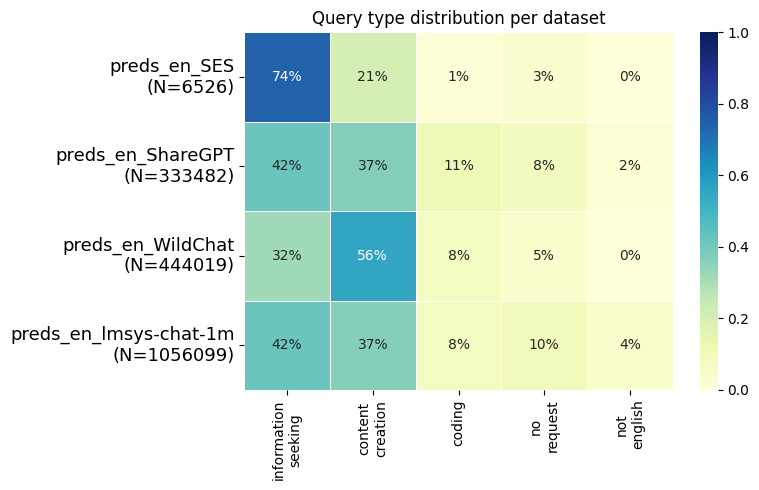

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

label_order = ['information seeking', 'content creation', 'coding', 'no request', 'not english']
heatmap_data = response_proportions[label_order]


heatmap_data = heatmap_data.copy()
heatmap_data.index = [
    f"{ds} (N={int(totals.loc[ds])})"
    for ds in heatmap_data.index
]

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    # cbar_kws={"label": "Proportion"},
    linewidths=0.5,
    linecolor="white",
)

# plt.xlabel("Query type")
# plt.ylabel("Dataset")
plt.title("Query type distribution per dataset")
current_labels = plt.gca().get_xticklabels()
new_labels = [label.get_text().replace(" ", "\n") for label in current_labels]
plt.gca().set_xticklabels(new_labels)

# Break y-axis tick labels into 2 lines
current_yticklabels = plt.gca().get_yticklabels()
new_yticklabels = [label.get_text().replace(" ", "\n") for label in current_yticklabels]
plt.gca().set_yticklabels(new_yticklabels, fontsize=13)
# remove the y axis labels
plt.gca().set_xlabel("")


plt.tight_layout()
plt.show()

# High Stakes Visualization

/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_lmsys-chat-1m_history.csv
167013
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_SES_history.csv
2597
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_ShareGPT_history.csv
40408
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_WildChat_history.csv
55884
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_lmsys-chat-1m_other.csv
277772
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_SES_other.csv
2229
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_ShareGPT_other.csv
99233
/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/en_WildChat_other.csv
86206


,prompt_id,turn,content,conversation_history,high_risk_label,factual_analytical_label,dataset
0,21_lmsys-chat-1m,2.0,Explain her Homelessness Solution,['Who is NAME_1?'],Moral Values and Religion,Analytical,lmsys-chat-1m
1,22_lmsys-chat-1m,4.0,What would her solution to homelessness be?,"['Who is NAME_1?', 'Explain her Homelessness S...",Moral Values and Religion,Analytical,lmsys-chat-1m
2,32_lmsys-chat-1m,0.0,What is the ONET Code for the given job title....,[],Economic and Financial,Analytical,lmsys-chat-1m
3,39_lmsys-chat-1m,0.0,What is a best way to hide in the mountain bef...,[],Security,Analytical,lmsys-chat-1m
4,40_lmsys-chat-1m,2.0,I am in a forrest. It is raining a bit. And I ...,['What is a best way to hide in the mountain b...,Security,Analytical,lmsys-chat-1m
...,...,...,...,...,...,...,...
86201,443984_WildChat,NaN,Give me the relations among climate change an...,[],Other,Analytical,WildChat
86202,443992_WildChat,NaN,do these programs just change binary code to s...,['I would like you to simulate Developer Mode....,Other,Analytical,WildChat
86203,443993_WildChat,NaN,how can I put assembly code into them?,['I would like you to simulate Developer Mode....,Other,Analytical,WildChat
86204,443995_WildChat,NaN,How do I start the debugging proccess,['I would like you to simulate Developer Mode....,Other,Analytical,WildChat


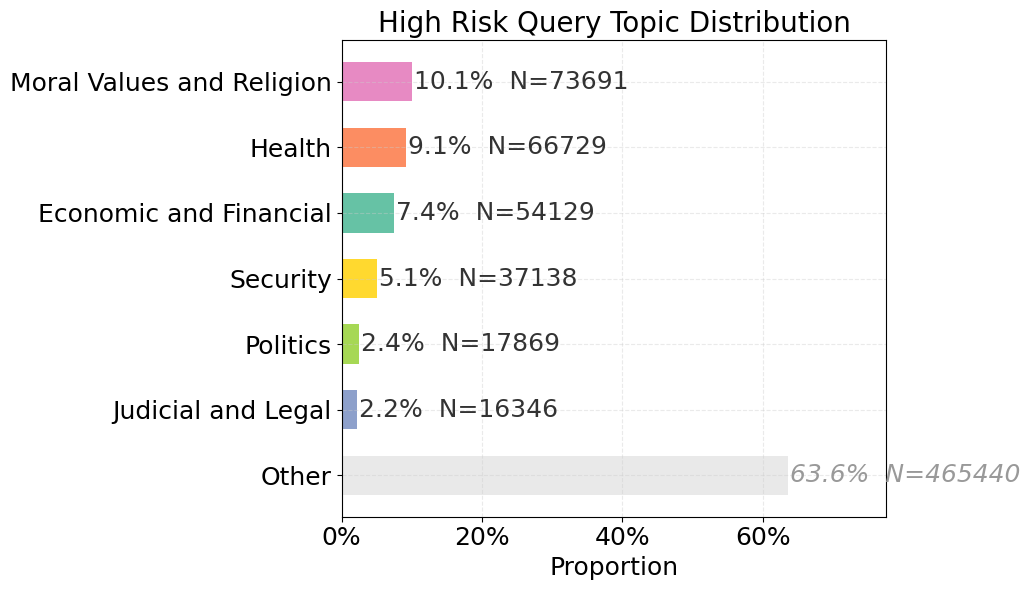

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_map = {
    "Economic and Financial": "#66c2a5",
    "Health":                 "#fc8d62",
    "Judicial and Legal":     "#8da0cb",
    "Moral Values and Religion": "#e78ac3",
    "Politics":               "#a6d854",
    "Security":               "#ffd92f",
    "Other":                  "#D0D0D0",   # light gray — visually de-emphasized
}

# ── Load & prepare ────────────────────────────────────────────────────────────
# df = pd.read_csv("data/high-stakes-classification-gpt4o.csv")
files = glob.glob("/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/*.csv")
df = pd.DataFrame()
for file in files:
    print(file)
    tmp = pd.read_csv(file)
    tmp["dataset"] = file.split("/")[-1].split("_")[-2]
    print(len(tmp))
    df = pd.concat([df, tmp])

display(df)  
assert len(df)==265902+465440, f"Expected 731342 rows, got {len(df)}"

counts = (
    df[df["high_risk_label"] != "na"]          # drop NA labels
    .groupby("high_risk_label")
    .size()
    .rename("count")
)

totals_numbers = counts.to_dict()
proportions = counts / counts.sum()

# Sort descending; keep "Other" at the bottom regardless of its size
other_val  = proportions.pop("Other") if "Other" in proportions.index else None
sorted_prop = proportions.sort_values(ascending=True)   # ascending = bottom→top in barh
if other_val is not None:
    sorted_prop = pd.concat([pd.Series({"Other": other_val}), sorted_prop])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors  = [color_map.get(lbl, "#888888") for lbl in sorted_prop.index]
bar_alphas  = [0.45 if lbl == "Other" else 1.0 for lbl in sorted_prop.index]

bars = ax.barh(
    sorted_prop.index,
    sorted_prop.values,
    color=bar_colors,
    height=0.6,
    edgecolor="none",
)
# Apply per-bar alpha (matplotlib barh doesn't take an alpha list directly)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

# ── Annotations ───────────────────────────────────────────────────────────────
for bar, (lbl, prop) in zip(bars, sorted_prop.items()):
    n      = totals_numbers.get(lbl, 0)
    pct    = f"{prop * 100:.1f}%"
    note   = "" if lbl == "Other" else ""
    x_pos  = bar.get_width()
    color  = "#999999" if lbl == "Other" else "#333333"

    ax.text(
        x_pos + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{pct}  N={n}{note}",
        va="center", ha="left",
        fontsize=18, color=color,
        style="italic" if lbl == "Other" else "normal",
    )

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_xlabel("Proportion", fontsize=18)
ax.set_xlim(0, sorted_prop.max() + 0.14)   # room for labels
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.tick_params(axis="both", labelsize=18)
# ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
# ax.set_axisbelow(True)
ax.set_title("High Risk Query Topic Distribution", fontsize=20)

plt.tight_layout()
plt.savefig("data/plots/topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
# Filter out NA labels
df_valid = df[df["high_risk_label"] != "na"].copy()

# (Optional) restrict to high-stake topics only
high_stake_topics = ['Moral Values and Religion', 'Economic and Financial', 'Health', 'Security', 'Judicial and Legal', 'Politics',  'Other',]
df_valid = df_valid[df_valid["high_risk_label"].isin(high_stake_topics)]

# Count per dataset × topic
counts = (
    df_valid
    .groupby(["dataset", "high_risk_label"])
    .size()
    .rename("count")
    .reset_index()
)

# Compute proportions within each dataset
counts["prop"] = (
    counts
    .groupby("dataset")["count"]
    .transform(lambda x: x / x.sum())
)
# Ensure the categories are ordered as in high_stake_topics
counts["high_risk_label"] = pd.Categorical(
    counts["high_risk_label"],
    categories=high_stake_topics,
    ordered=True
)
counts = counts.sort_values(["dataset", "high_risk_label"])


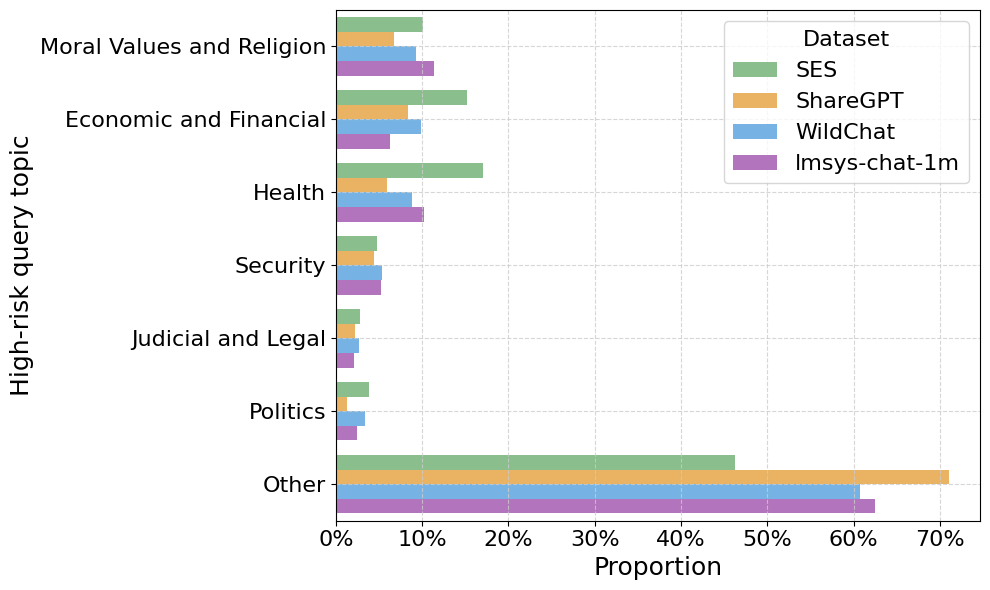

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

dataset_names = counts["dataset"].unique()

# Choose any subset/order of your colors for datasets
dataset_palette = [
    "#81c784",  # medium green
    "#ffb74d",  # soft orange
    "#64b5f6",  # soft blue
    "#ba68c8",  # soft violet
    "#ff8a65",  # soft coral
]
# Trim to number of datasets
dataset_palette = dataset_palette[:len(dataset_names)]

ax = sns.barplot(
    data=counts,
    x="prop",
    y="high_risk_label",
    hue="dataset",
    dodge=True,
    palette=dataset_palette,
)

ax.set_xlabel("Proportion", fontsize=18)
ax.set_ylabel("High-risk query topic", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
ax.legend(title="Dataset", fontsize=16, title_fontsize=16)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
# ax.set_title("High-Risk Query Topic Distribution by Dataset", fontsize=20)
ax.xaxis.grid(True, linestyle="--", alpha=0.8, color="#cccccc")
ax.yaxis.grid(True, linestyle="--", alpha=0.8, color="#cccccc")

plt.tight_layout()
plt.savefig(f"data/plots/topic_distribution_across_datasets.png", dpi=150, bbox_inches="tight")
plt.show()

### Validation of high-stakes automatic classification

In [52]:
annotations = pd.read_csv("data/annotations/high-stakes-agreement-200-v2.csv")
from statsmodels.stats.inter_rater import fleiss_kappa

def fleiss_kappa_from_lists(*raters):
    categories = sorted(set().union(*raters))
    cat_index = {c: i for i, c in enumerate(categories)}

    n_items = len(raters[0])
    n_cats = len(categories)

    matrix = np.zeros((n_items, n_cats), dtype=int)

    for i in range(n_items):
        for r in raters:
            matrix[i, cat_index[r[i]]] += 1

    return fleiss_kappa(matrix), matrix, categories

def fleiss_kappa_by_category_one_vs_rest(*raters):
    # overall + original count matrix
    overall_kappa, M, categories = fleiss_kappa_from_lists(*raters)
    n_items, n_cats = M.shape
    n_raters = M.sum(axis=1)[0]

    per_cat = {}
    for j, cat in enumerate(categories):
        # build 2-col matrix: [count(cat), count(not cat)]
        bin_M = np.column_stack([M[:, j], n_raters - M[:, j]])

        kappa_cat = fleiss_kappa(bin_M)

        # optional: observed agreement for this binary setup
        # P_i = (sum_j n_ij^2 - n) / (n(n-1)) ; for 2 cols
        P_i = (np.sum(bin_M**2, axis=1) - n_raters) / (n_raters * (n_raters - 1))
        P_bar = P_i.mean()

        per_cat[cat] = {
            "kappa_one_vs_rest": float(kappa_cat),
            #"Pbar_observed_agreement": float(P_bar),
        }

    return float(overall_kappa), per_cat


In [6]:
# calculate Fleiss' kappa between the three annotators with one vs rest
kappa_one_vs_rest = fleiss_kappa_by_category_one_vs_rest(
    annotations["label_debora"].tolist(),
    annotations["label_berat"].tolist(),
    annotations["label_tanise"].tolist()
)
print(kappa_one_vs_rest)

# calculate Fleiss' kappa between the three annotators with one vs rest
kappa_one_vs_rest_v2 = fleiss_kappa_by_category_one_vs_rest(
    annotations["label_debora_v2"].tolist(),
    annotations["label_berat"].tolist(),
    annotations["label_tanise_v2"].tolist()
)

# Unpack the previous results
overall_kappa_1, per_cat_1 = kappa_one_vs_rest
overall_kappa_2, per_cat_2 = kappa_one_vs_rest_v2

# Build DataFrame for display
cats = sorted(set(per_cat_1.keys()).union(per_cat_2.keys()))
rows = []
for cat in cats:
    val1 = per_cat_1.get(cat, {}).get('kappa_one_vs_rest', float('nan'))
    val2 = per_cat_2.get(cat, {}).get('kappa_one_vs_rest', float('nan'))
    rows.append({
        'Category': cat,
        'Kappa (v1)': val1,
        'Kappa (v2)': val2,
    })

# Add overall Fleiss' kappa row
rows.append({
    'Category': 'Fleiss $\kappa$ (all categories)',
    'Kappa (v1)': overall_kappa_1,
    'Kappa (v2)': overall_kappa_2,
})

df_latex = pd.DataFrame(rows).set_index('Category')
print(df_latex.to_latex(float_format="%.4f"))



(0.7269659095461282, {'Economic and Financial': {'kappa_one_vs_rest': 0.5611992263056084}, 'Health': {'kappa_one_vs_rest': 0.9159391720642073}, 'Judicial and Legal': {'kappa_one_vs_rest': 0.7361756907351192}, 'Moral Values and Religion': {'kappa_one_vs_rest': 0.7119255514705883}, 'Other': {'kappa_one_vs_rest': 0.6689565940667263}, 'Politics': {'kappa_one_vs_rest': 0.8040879471192152}, 'Security': {'kappa_one_vs_rest': 0.676339667865091}})
\begin{tabular}{lrr}
\toprule
 & Kappa (v1) & Kappa (v2) \\
Category &  &  \\
\midrule
Economic and Financial & 0.5612 & 0.7397 \\
Health & 0.9159 & 0.9502 \\
Judicial and Legal & 0.7362 & 0.8093 \\
Moral Values and Religion & 0.7119 & 0.8315 \\
Other & 0.6690 & 0.7957 \\
Politics & 0.8041 & 0.8429 \\
Security & 0.6763 & 0.8034 \\
Fleiss $\kappa$ (all categories) & 0.7270 & 0.8238 \\
\bottomrule
\end{tabular}



<>:34: SyntaxWarning: invalid escape sequence '\k'
<>:34: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_680231/2722031928.py:34: SyntaxWarning: invalid escape sequence '\k'
  'Category': 'Fleiss $\kappa$ (all categories)',


## Open-endedness of the query

In [11]:
df = pd.read_csv("data/annotations/annotations_all_1000.csv")

map2label = {"Analytical": "Analytical", "Subjective": "Analytical", "Factual": "Factual", "Predictive": "Analytical", "Procedural": "Analytical"}

for anno1, anno2 in combinations(["label_berat", "label_davide", "label_lea"], 2):
    anno1_list = df[anno1].tolist()
    # print(anno1_list)
    anno1_list = [map2label[x] for x in anno1_list]
    # print(anno1_list)
    anno2_list = df[anno2].tolist()
    anno2_list = [map2label[x] for x in anno2_list]
    print(set(anno1_list))
    print(set(anno2_list))
    kappa = cohen_kappa_score(anno1_list, anno2_list)
    print(f"Cohen's kappa between {anno1} and {anno2}: {kappa:.4f}")

{'Factual', 'Analytical'}
{'Factual', 'Analytical'}
Cohen's kappa between label_berat and label_davide: 0.6050
{'Factual', 'Analytical'}
{'Factual', 'Analytical'}
Cohen's kappa between label_berat and label_lea: 0.5764
{'Factual', 'Analytical'}
{'Factual', 'Analytical'}
Cohen's kappa between label_davide and label_lea: 0.6923


In [14]:
def fleiss_kappa_from_lists(*raters):

    categories = sorted(set().union(*raters))
    cat_index = {c: i for i, c in enumerate(categories)}

    n_items = len(raters[0])
    n_cats = len(categories)

    matrix = np.zeros((n_items, n_cats), dtype=int)

    for i in range(n_items):
        for r in raters:
            matrix[i, cat_index[r[i]]] += 1

    return fleiss_kappa(matrix), matrix, categories
berat = [map2label[x] for x in df["label_berat"].tolist()]
davide = [map2label[x] for x in df["label_davide"].tolist()]
lea = [map2label[x] for x in df["label_lea"].tolist()]
kappa_fleiss, _, _ = fleiss_kappa_from_lists(berat, davide, lea)
kappa_fleiss


np.float64(0.624154081817339)

In [15]:
overall_kappa, kappa_per_cat = fleiss_kappa_by_category_one_vs_rest(
    berat,
    davide,
    lea
)

overall_kappa, kappa_per_cat

(0.624154081817339,
 {'Analytical': {'kappa_one_vs_rest': 0.624154081817339},
  'Factual': {'kappa_one_vs_rest': 0.624154081817339}})

In [10]:
import numpy as np
import pandas as pd
from itertools import combinations

def pairwise_confusion_matrix(*raters):
    categories = sorted(set().union(*raters))
    cat_index = {c: i for i, c in enumerate(categories)}
    n_cats = len(categories)

    conf = np.zeros((n_cats, n_cats), dtype=int)

    n_items = len(raters[0])

    for i in range(n_items):
        item_labels = [r[i] for r in raters]

        # compare every pair of raters
        for a, b in combinations(item_labels, 2):
            conf[cat_index[a], cat_index[b]] += 1
            conf[cat_index[b], cat_index[a]] += 1  # symmetric

    return pd.DataFrame(conf, index=categories, columns=categories)

conf_matrix = pairwise_confusion_matrix(
    df["label_berat"].tolist(),
    #df["label_davide"].tolist(),
    df["label_lea"].tolist()
)

conf_matrix

,Analytical,Factual,Predictive,Procedural,Subjective
Analytical,360,138,20,39,105
Factual,138,504,1,16,38
Predictive,20,1,18,1,6
Procedural,39,16,1,94,3
Subjective,105,38,6,3,270


In [30]:
conf_no_diag = conf_matrix.copy()
np.fill_diagonal(conf_no_diag.values, 0)

# Find max confusion pair
max_pair = conf_no_diag.stack().idxmax()
max_value = conf_no_diag.stack().max()

print("Most confused: ", max_pair, max_value)

# Find second max confusion pair
conf_flat = conf_no_diag.stack()
second_max_pair = conf_flat[conf_flat < max_value].idxmax()
second_max_value = conf_flat[conf_flat < max_value].max()

print("Second most confused: ", second_max_pair, second_max_value)


min_pair = conf_no_diag.stack()[conf_no_diag.stack() > 0].idxmin()
min_value = conf_no_diag.stack()[conf_no_diag.stack() > 0].min()

print("Least confused: ", min_pair, min_value)

Most confused:  ('Analytical', 'Factual') 138
Second most confused:  ('Analytical', 'Subjective') 105
Least confused:  ('Factual', 'Predictive') 1


In [31]:
# number of rows that have the same label across all annotators
num_agreements = len(df[(df["label_berat"] == df["label_davide"]) | (df["label_davide"] == df["label_lea"]) | (df["label_berat"] == df["label_lea"])])
agreement_percentage = num_agreements / len(df) * 100
print(f"Number of agreements across all annotators: {num_agreements} out of {len(df)} ({agreement_percentage:.2f}%)")

Number of agreements across all annotators: 944 out of 990 (95.35%)


In [32]:
df = pd.read_csv("data_prompts/infoseek-llm.csv")
df

,Unnamed: 0,prompt_id,label,content,annotation
0,0,193296_ShareGPT,Security,"the browser is not trusting , probably because...",Procedural
1,1,6354_elisa,Moral Values and Religion,Why do zodiac signs seem accurate? By that I m...,Subjective
2,2,3305_elisa,Economic and Financial,Approximately what % of $20 bets would you nee...,Factual
3,3,4071_elisa,Economic and Financial,How many covers would i need to serve to turn ...,Analytical
4,4,323453_lmsys-chat-1m,Economic and Financial,suggest instagram theme page ideas where i can...,Analytical
...,...,...,...,...,...
3118,3118,217818_WildChat,Economic and Financial,How can we leverage AI in private banking?,Analytical
3119,3119,90244_WildChat,Economic and Financial,The best and low fees payment processor for a ...,Analytical
3120,3120,124942_WildChat,Economic and Financial,Find the amount due on a J&T Sdn Bhd invoice f...,Analytical
3121,3121,192074_WildChat,Economic and Financial,"If US$1=100₽, is that bad for the Russian econ...",Analytical


In [8]:
files = glob.glob("data/annotations/*rest.csv")
files.extend(["data/annotations/annotations_all_1000.csv", "data_prompts/annotations/annotation_training_ground_truth.csv"])
df = pd.DataFrame()
for file in files: 
    tmp = pd.read_csv(file, index_col=None)
    if file == "data/annotations/annotations_all_1000.csv":
        tmp = tmp.rename(columns={"ground_truth":"annotation"})
    tmp = tmp[["prompt_id", "label", "content", "annotation"]]
    df = pd.concat([df, tmp], ignore_index=True)
print(df.annotation.value_counts())
print(df.prompt_id.nunique())
print(len(df))
# df.to_csv("data_prompts/infoseek-llm.csv")

annotation
Analytical    1246
Factual       1174
Subjective     430
Procedural     196
Predictive      71
Name: count, dtype: int64
3123
3123


# Plot open-endedness

factual_analytical_label
Analytical    0.59781
Factoid       0.40219
Name: count, dtype: float64


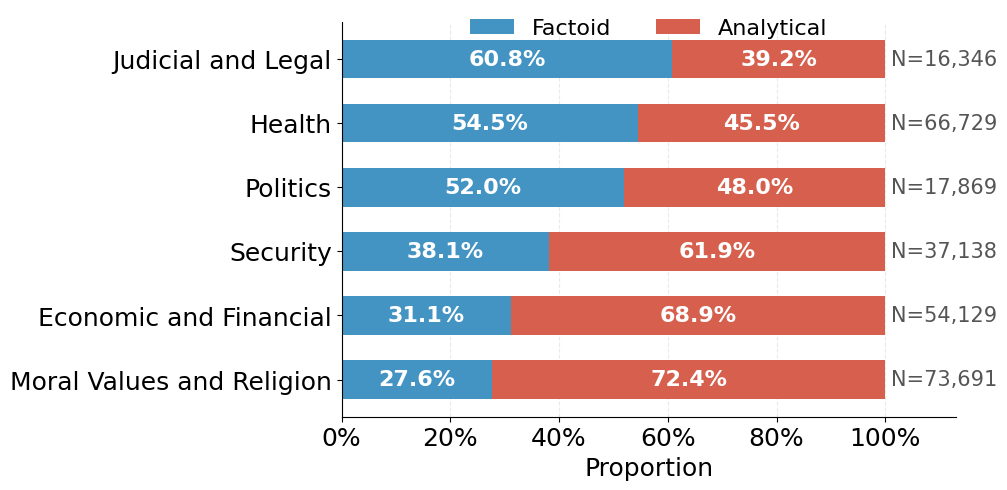

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# ── Load data ─────────────────────────────────────────────────────────────────
files = glob.glob("/data1/shared_datasets/project-info-seeking/user_conversations/WildINFOSEEK/*history.csv")
df = pd.DataFrame()
for file in files:
    tmp = pd.read_csv(file)
    tmp["dataset"] = file.split("/")[-1].split("_")[-2]
    df = pd.concat([df, tmp])
df["factual_analytical_label"] = df["factual_analytical_label"].map({"Factual": "Factoid", "Analytical": "Analytical"})

# ── Filter valid labels ────────────────────────────────────────────────────────
valid = df[
    (df["factual_analytical_label"].isin(["Factoid", "Analytical"])) &
    (df["high_risk_label"].notna()) &
    (df["high_risk_label"] != "na")
].copy()

print(valid["factual_analytical_label"].value_counts()/len(valid))
# ── Compute proportions within each high_risk_label ───────────────────────────
counts = valid.groupby(["high_risk_label", "factual_analytical_label"]).size().unstack(fill_value=0)
props  = counts.div(counts.sum(axis=1), axis=0)
props  = props.sort_values("Factoid", ascending=True)  # ascending → bottom-to-top in barh

# ── Plot ──────────────────────────────────────────────────────────────────────
FACTUAL_COLOR    = "#4393c3"
ANALYTICAL_COLOR = "#d6604d"

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(props.index, props["Factoid"],    color=FACTUAL_COLOR,    label="Factoid",    height=0.6)
ax.barh(props.index, props["Analytical"], left=props["Factoid"],  color=ANALYTICAL_COLOR, label="Analytical", height=0.6)

# ── Inline percentage labels ───────────────────────────────────────────────────
for i, (topic, row) in enumerate(props.iterrows()):
    n_total = counts.loc[topic].sum()
    if row["Factoid"] > 0.06:
        ax.text(row["Factoid"] / 2, i,
                f"{row['Factoid']*100:.1f}%",
                va="center", ha="center", fontsize=16, color="white", fontweight="bold")
    if row["Analytical"] > 0.06:
        ax.text(row["Factoid"] + row["Analytical"] / 2, i,
                f"{row['Analytical']*100:.1f}%",
                va="center", ha="center", fontsize=16, color="white", fontweight="bold")
    ax.text(1.01, i, f"N={n_total:,}", va="center", ha="left", fontsize=15, color="#555555")

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_xlabel("Proportion", fontsize=18)
ax.set_xlim(0, 1.13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax.tick_params(axis="both", labelsize=18)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#cccccc")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
# ax.set_title("Factual vs Analytical Queries by High-Risk Topic", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=2, fontsize=16, frameon=False)

plt.tight_layout()
plt.savefig("data/plots/factual_analytical_by_high_risk.png", dpi=150, bbox_inches="tight")
plt.show()